# Geo features EDA: `customer_seller_distance_km`, `same_state`, `seller_state_seller_count`

This notebook is the EDA case for the three geo-derived features added in this
change: two computed by `src/geo_features.py` from raw customer/seller
lat-lng (`customer_seller_distance_km`, `same_state`), plus
`seller_state_seller_count`, a market-density feature computed directly in
`queries/repeat_purchase_features.sql`. See that query's `first_order_geo`
and `seller_state_counts` CTEs for how the raw inputs are built.

Goal: check these features are clean enough to trust (nulls, ranges,
distributions), establish whether they actually relate to `repeat_purchase`
(hypothesis tests + correlation), sanity-check them against features they
should plausibly track (freight cost, delivery time), and tie the result back
to what the fitted model in `src/repeat_purchase_analysis.py` actually did
with them - so there's a defensible answer to "why is this feature in the
model" beyond "it seemed reasonable."

Data is loaded through `repeat_purchase_analysis.load_features()` - the same
function the production model trains on - so this EDA can't silently drift
from what the model actually sees.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import chi2_contingency, pointbiserialr, ttest_ind

from db import get_engine
from repeat_purchase_analysis import CATEGORICAL_FEATURES, NUMERIC_FEATURES, TARGET, load_features

pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
pd.set_option("display.width", 120)

In [2]:
# Validated categorical palette (dataviz skill's reference palette) - used
# consistently throughout: blue = 0 / No / one-time, orange = 1 / Yes / repeat.
BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, INK_SECONDARY, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
DIVERGING = LinearSegmentedColormap.from_list("blue_gray_red", ["#2a78d6", "#f0efec", "#e34948"])

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK,
    "axes.titlecolor": INK,
    "text.color": INK,
    "xtick.color": INK_SECONDARY,
    "ytick.color": INK_SECONDARY,
    "grid.color": GRID,
    "font.size": 11,
    "axes.grid": False,
})


def style_axes(ax):
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(GRID)
    ax.tick_params(colors=INK_SECONDARY)

## 0. Load data

Reuses the production feature-loading path (SQL query + `add_geo_features()`)
so this notebook is checking exactly what the model trains on.

In [3]:
engine = get_engine()
df = load_features(engine)

GEO_RAW_COLS = ["customer_lat", "customer_lng", "seller_state", "seller_lat", "seller_lng"]
GEO_MODEL_COLS = ["customer_seller_distance_km", "same_state", "seller_state_seller_count"]

print(f"{len(df):,} first-time customers loaded")
print(f"repeat_purchase rate: {df[TARGET].mean():.2%}  ({df[TARGET].sum():,} of {len(df):,})")
df[GEO_RAW_COLS + GEO_MODEL_COLS].head()

83,644 first-time customers loaded
repeat_purchase rate: 3.31%  (2,768 of 83,644)


,customer_lat,customer_lng,seller_state,seller_lat,seller_lng,customer_seller_distance_km,same_state,seller_state_seller_count
0,-23.340,-46.830,SP,-22.709,-47.665,110.569,1.000,1849
1,-23.559,-46.788,SP,-23.491,-46.583,22.168,1.000,1849
2,-27.543,-48.633,SP,-23.212,-46.763,516.939,0.000,1849
3,-1.312,-48.483,SP,-23.543,-46.490,"2,481.287",0.000,1849
4,-23.506,-47.470,SP,-23.302,-45.972,154.508,1.000,1849


## 1. Missing data

`first_order_geo` left-joins `geolocation` by zip-code prefix and `sellers`
by `seller_id`, so a handful of first orders can miss a geolocation match
(rare, per `src/etl.py`'s `load_geolocation()` comment) or have no seller row
at all. Checking the missingness lines up with that explanation - not some
other join bug - before trusting anything downstream.

In [4]:
null_summary = (
    df[GEO_RAW_COLS + GEO_MODEL_COLS]
    .isna()
    .sum()
    .rename("n_missing")
    .to_frame()
    .assign(pct_missing=lambda d: (d["n_missing"] / len(df) * 100).round(2))
)
null_summary

,n_missing,pct_missing
customer_lat,226,0.270
customer_lng,226,0.270
seller_state,0,0.000
seller_lat,198,0.240
seller_lng,198,0.240
customer_seller_distance_km,423,0.510
same_state,0,0.000
seller_state_seller_count,0,0.000


In [5]:
# Consistency check: same_state should be null EXACTLY where customer_state or
# seller_state is null (this is also asserted in tests/test_repeat_purchase_features.py) -
# and customer_seller_distance_km should be null exactly where any of the four
# coordinates is null. If either check fails here, add_geo_features() and the
# SQL join have drifted apart.
expected_same_state_null = df["customer_state"].isna() | df["seller_state"].isna()
same_state_null_matches = df["same_state"].isna().equals(expected_same_state_null)

expected_distance_null = df[["customer_lat", "customer_lng", "seller_lat", "seller_lng"]].isna().any(axis=1)
distance_null_matches = df["customer_seller_distance_km"].isna().equals(expected_distance_null)

print(f"same_state null pattern matches customer_state/seller_state nulls: {same_state_null_matches}")
print(f"customer_seller_distance_km null pattern matches coordinate nulls:  {distance_null_matches}")

same_state null pattern matches customer_state/seller_state nulls: True
customer_seller_distance_km null pattern matches coordinate nulls:  True


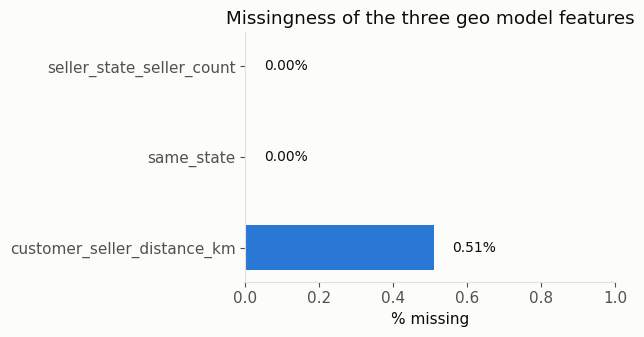

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 3.5))
missing_model_cols = null_summary.loc[GEO_MODEL_COLS, "pct_missing"]
bars = ax.barh(missing_model_cols.index, missing_model_cols.values, color=BLUE, height=0.5)
for bar, val in zip(bars, missing_model_cols.values):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2, f"{val:.2f}%",
            va="center", ha="left", color=INK, fontsize=10)
ax.set_xlabel("% missing")
ax.set_title("Missingness of the three geo model features")
ax.set_xlim(0, max(1.0, missing_model_cols.max() * 1.4))
style_axes(ax)
plt.tight_layout()
plt.show()

## 2. `same_state` (binary)

1 = the customer's first order shipped from a seller in their own state, 0 =
it didn't, NaN = customer or seller state unknown.

In [7]:
same_state_counts = df["same_state"].value_counts(dropna=False).sort_index()
same_state_table = pd.DataFrame({
    "count": same_state_counts,
    "pct_of_all_rows": (same_state_counts / len(df) * 100).round(2),
})
same_state_table.index = same_state_table.index.map(
    lambda v: "Different state (0)" if v == 0 else ("Same state (1)" if v == 1 else "Unknown (NaN)")
)
same_state_table

,count,pct_of_all_rows
same_state,,
Different state (0),54226,64.830
Same state (1),29418,35.170


In [8]:
repeat_rate_by_match = (
    df.dropna(subset=["same_state"])
    .groupby("same_state")[TARGET]
    .agg(n="count", repeat_rate=lambda s: s.mean() * 100)
)
repeat_rate_by_match.index = repeat_rate_by_match.index.map({0.0: "Different state", 1.0: "Same state"})
print("Repeat-purchase rate by state match:")
repeat_rate_by_match

Repeat-purchase rate by state match:


,n,repeat_rate
same_state,,
Different state,54226,3.229
Same state,29418,3.457


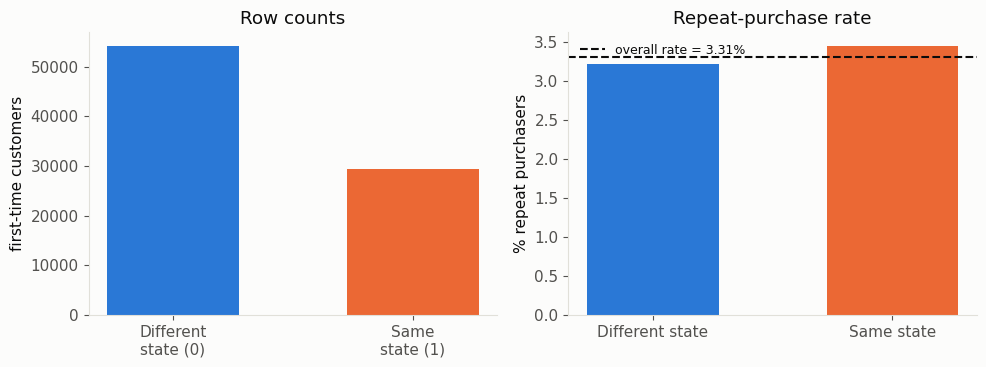

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

counts = same_state_counts.reindex([0.0, 1.0])
axes[0].bar(["Different\nstate (0)", "Same\nstate (1)"], counts.values, color=[BLUE, ORANGE], width=0.55)
axes[0].set_title("Row counts")
axes[0].set_ylabel("first-time customers")
style_axes(axes[0])

axes[1].bar(repeat_rate_by_match.index, repeat_rate_by_match["repeat_rate"], color=[BLUE, ORANGE], width=0.55)
axes[1].axhline(df[TARGET].mean() * 100, color=INK, linestyle="--", linewidth=1.5,
                 label=f"overall rate = {df[TARGET].mean() * 100:.2f}%")
axes[1].set_title("Repeat-purchase rate")
axes[1].set_ylabel("% repeat purchasers")
axes[1].legend(frameon=False, fontsize=9)
style_axes(axes[1])

plt.tight_layout()
plt.show()

## 3. `customer_seller_distance_km` (continuous)

Haversine distance between the customer's and seller's zip-prefix
centroids, in km.

In [10]:
distance = df["customer_seller_distance_km"].dropna()

print(f"customer_seller_distance_km  (n={len(distance):,}, {df['customer_seller_distance_km'].isna().mean():.2%} missing)")
print(f"  mean    = {distance.mean():,.1f} km")
print(f"  median  = {distance.median():,.1f} km")
print(f"  std     = {distance.std():,.1f} km")
print(f"  min     = {distance.min():,.1f} km")
print(f"  max     = {distance.max():,.1f} km")
print()
distance.describe(percentiles=[.05, .25, .5, .75, .9, .95, .99]).to_frame("customer_seller_distance_km")

customer_seller_distance_km  (n=83,221, 0.51% missing)
  mean    = 609.2 km
  median  = 441.3 km
  std     = 596.8 km
  min     = 0.0 km
  max     = 5,338.6 km



,customer_seller_distance_km
count,"83,221.000"
mean,609.166
std,596.773
min,0.000
5%,17.096
25%,200.896
50%,441.291
75%,806.758
90%,"1,467.280"
95%,"2,103.720"


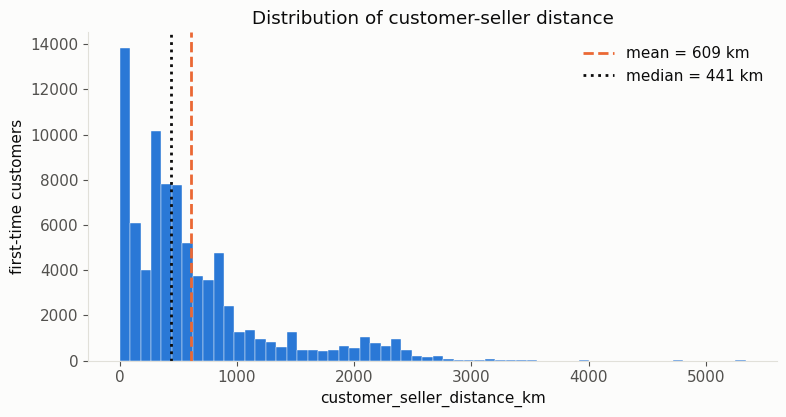

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.3))
ax.hist(distance, bins=60, color=BLUE, edgecolor=SURFACE, linewidth=0.3)
ax.axvline(distance.mean(), color=ORANGE, linewidth=2, linestyle="--", label=f"mean = {distance.mean():,.0f} km")
ax.axvline(distance.median(), color=INK, linewidth=2, linestyle=":", label=f"median = {distance.median():,.0f} km")
ax.set_xlabel("customer_seller_distance_km")
ax.set_ylabel("first-time customers")
ax.set_title("Distribution of customer-seller distance")
ax.legend(frameon=False)
style_axes(ax)
plt.tight_layout()
plt.show()

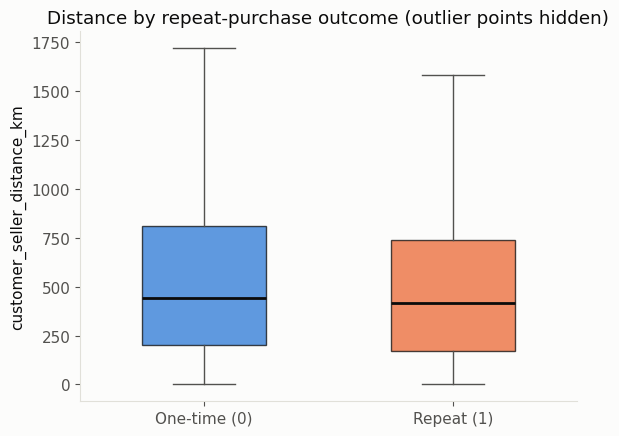

In [12]:
fig, ax = plt.subplots(figsize=(6, 4.5))
by_target = [
    df.loc[df[TARGET] == 0, "customer_seller_distance_km"].dropna(),
    df.loc[df[TARGET] == 1, "customer_seller_distance_km"].dropna(),
]
bp = ax.boxplot(by_target, tick_labels=["One-time (0)", "Repeat (1)"], patch_artist=True,
                 showfliers=False, widths=0.5, medianprops={"color": INK, "linewidth": 2})
for patch, color in zip(bp["boxes"], [BLUE, ORANGE]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
    patch.set_edgecolor(INK)
for element in ["whiskers", "caps"]:
    plt.setp(bp[element], color=INK_SECONDARY)
ax.set_ylabel("customer_seller_distance_km")
ax.set_title("Distance by repeat-purchase outcome (outlier points hidden)")
style_axes(ax)
plt.tight_layout()
plt.show()

## 4. `seller_state_seller_count` (continuous, bonus feature)

Not one of `geo_features.py`'s two haversine outputs, but new in this same
change (`seller_state_counts` CTE) and worth the same treatment: how many
sellers operate out of the customer's first-order seller's state - a proxy
for how established/competitive that state's seller base is.

In [13]:
seller_count = df["seller_state_seller_count"].dropna()

print(f"seller_state_seller_count  (n={len(seller_count):,}, {df['seller_state_seller_count'].isna().mean():.2%} missing)")
print(f"  mean    = {seller_count.mean():,.1f} sellers")
print(f"  median  = {seller_count.median():,.1f} sellers")
print(f"  std     = {seller_count.std():,.1f} sellers")
print(f"  min     = {seller_count.min():,.0f} sellers")
print(f"  max     = {seller_count.max():,.0f} sellers")
print()
seller_count.describe(percentiles=[.05, .25, .5, .75, .9, .95, .99]).to_frame("seller_state_seller_count")

seller_state_seller_count  (n=83,644, 0.00% missing)
  mean    = 1,375.7 sellers
  median  = 1,849.0 sellers
  std     = 741.4 sellers
  min     = 1 sellers
  max     = 1,849 sellers



,seller_state_seller_count
count,"83,644.000"
mean,"1,375.672"
std,741.369
min,1.000
5%,129.000
25%,349.000
50%,"1,849.000"
75%,"1,849.000"
90%,"1,849.000"
95%,"1,849.000"


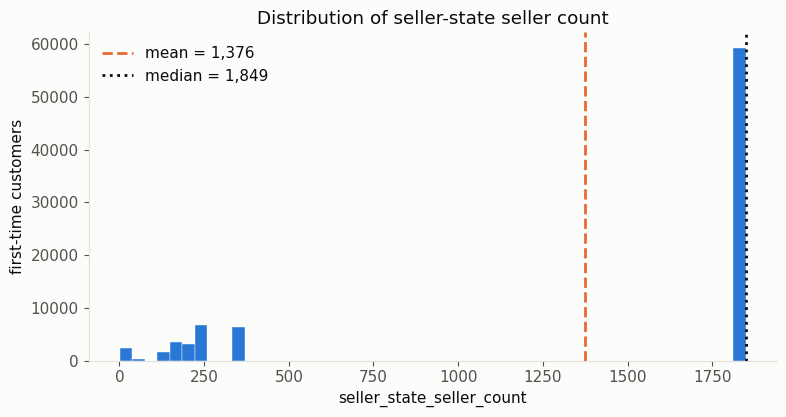

In [14]:
fig, ax = plt.subplots(figsize=(8, 4.3))
ax.hist(seller_count, bins=50, color=BLUE, edgecolor=SURFACE, linewidth=0.3)
ax.axvline(seller_count.mean(), color=ORANGE, linewidth=2, linestyle="--", label=f"mean = {seller_count.mean():,.0f}")
ax.axvline(seller_count.median(), color=INK, linewidth=2, linestyle=":", label=f"median = {seller_count.median():,.0f}")
ax.set_xlabel("seller_state_seller_count")
ax.set_ylabel("first-time customers")
ax.set_title("Distribution of seller-state seller count")
ax.legend(frameon=False)
style_axes(ax)
plt.tight_layout()
plt.show()

## 5. Correlation with `repeat_purchase`

Point-biserial correlation is just Pearson correlation with a 0/1 variable,
so the same function (`scipy.stats.pointbiserialr`) covers the two continuous
geo features and, treated as 0/1, `same_state` too - which puts all three
geo features on one ranked table alongside every other feature already in
the model, so stakeholders can see where they land rather than taking
"it's in the model" on faith.

In [15]:
def point_biserial_vs_target(feature: str, frame: pd.DataFrame = df) -> tuple[float, float, int]:
    paired = frame[[feature, TARGET]].dropna()
    r, p = pointbiserialr(paired[TARGET], paired[feature])
    return r, p, len(paired)


rows = []
for feat in NUMERIC_FEATURES:
    r, p, n = point_biserial_vs_target(feat)
    rows.append({"feature": feat, "corr_with_target": r, "p_value": p, "n": n,
                  "is_geo_feature": feat in GEO_MODEL_COLS})

corr_table = (
    pd.DataFrame(rows)
    .assign(abs_corr=lambda d: d["corr_with_target"].abs())
    .sort_values("abs_corr", ascending=False)
    .drop(columns="abs_corr")
    .reset_index(drop=True)
)
corr_table

,feature,corr_with_target,p_value,n,is_geo_feature
0,payment_installments,0.026,0.000,83643,False
1,num_items,0.025,0.000,83644,False
2,customer_seller_distance_km,-0.015,0.000,83221,True
3,items_price,-0.013,0.000,83644,False
4,delivery_delay_days,-0.013,0.000,83644,False
5,payment_value,-0.012,0.000,83643,False
6,delivery_time_days,-0.010,0.002,83644,False
7,review_score,0.007,0.041,83045,False
8,same_state,0.006,0.078,83644,True
9,seller_state_seller_count,0.004,0.235,83644,True


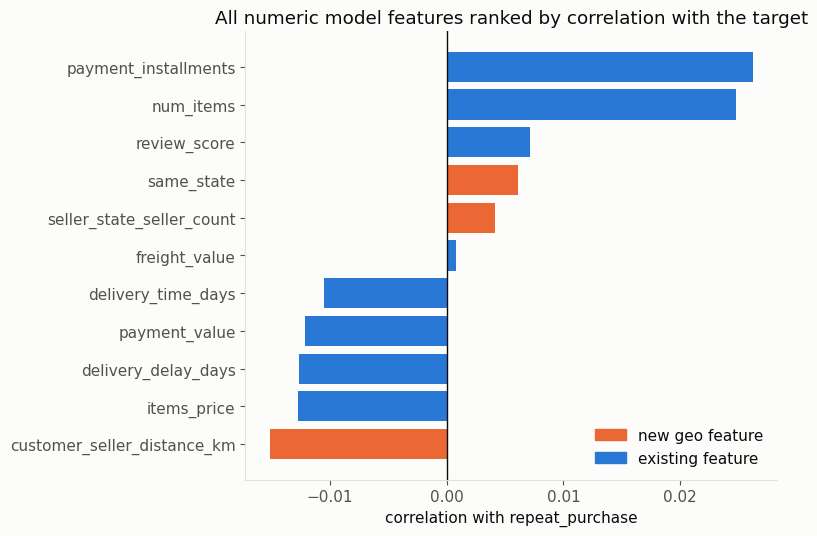

In [16]:
plot_table = corr_table.sort_values("corr_with_target")
colors = [ORANGE if is_geo else BLUE for is_geo in plot_table["is_geo_feature"]]

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(plot_table["feature"], plot_table["corr_with_target"], color=colors)
ax.axvline(0, color=INK, linewidth=1)
ax.set_xlabel("correlation with repeat_purchase")
ax.set_title("All numeric model features ranked by correlation with the target")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=ORANGE, label="new geo feature"), Patch(color=BLUE, label="existing feature")],
          frameon=False, loc="lower right")
style_axes(ax)
plt.tight_layout()
plt.show()

## 6. Hypothesis tests

Same style as `repeat_purchase_analysis.run_hypothesis_tests()`: Welch's
t-test (unequal variances assumed) + Cohen's d for a continuous feature
against the binary target, chi-square test of independence + Cramer's V for
a categorical/binary feature against the binary target. Effect sizes are
reported next to the p-values on purpose - at this sample size, even a
practically tiny difference can be statistically significant.

In [17]:
print("=== H1: customer_seller_distance_km differs between repeat and one-time buyers ===")
repeat_dist = df.loc[df[TARGET] == 1, "customer_seller_distance_km"].dropna()
onetime_dist = df.loc[df[TARGET] == 0, "customer_seller_distance_km"].dropna()

t_stat, p_val = ttest_ind(repeat_dist, onetime_dist, equal_var=False)
n1, n2 = len(repeat_dist), len(onetime_dist)
pooled_sd = np.sqrt(((n1 - 1) * repeat_dist.var() + (n2 - 1) * onetime_dist.var()) / (n1 + n2 - 2))
cohens_d_dist = (repeat_dist.mean() - onetime_dist.mean()) / pooled_sd

print(f"repeat   (n={n1:,}): mean={repeat_dist.mean():,.1f} km")
print(f"one-time (n={n2:,}): mean={onetime_dist.mean():,.1f} km")
print(f"Welch's t={t_stat:.2f}, p={p_val:.4g}, Cohen's d={cohens_d_dist:.4f}")

=== H1: customer_seller_distance_km differs between repeat and one-time buyers ===
repeat   (n=2,748): mean=560.2 km
one-time (n=80,473): mean=610.8 km
Welch's t=-4.75, p=2.133e-06, Cohen's d=-0.0849


In [18]:
print("=== H2: repeat-purchase rate differs by same_state ===")
contingency_state = pd.crosstab(df["same_state"], df[TARGET])
chi2_state, p_state, dof_state, _ = chi2_contingency(contingency_state)
n_state = contingency_state.values.sum()
cramers_v_state = np.sqrt(chi2_state / (n_state * (min(contingency_state.shape) - 1)))

print(contingency_state.assign(repeat_rate_pct=lambda d: round(100 * d[1] / (d[0] + d[1]), 2)))
print(f"chi2={chi2_state:.2f}, dof={dof_state}, p={p_state:.4g}, Cramer's V={cramers_v_state:.4f}")

=== H2: repeat-purchase rate differs by same_state ===
repeat_purchase      0     1  repeat_rate_pct
same_state                                   
0.000            52475  1751            3.230
1.000            28401  1017            3.460
chi2=3.03, dof=1, p=0.08188, Cramer's V=0.0060


In [19]:
print("=== Bonus H3: seller_state_seller_count differs between repeat and one-time buyers ===")
repeat_ssc = df.loc[df[TARGET] == 1, "seller_state_seller_count"].dropna()
onetime_ssc = df.loc[df[TARGET] == 0, "seller_state_seller_count"].dropna()

t_stat_ssc, p_val_ssc = ttest_ind(repeat_ssc, onetime_ssc, equal_var=False)
n1s, n2s = len(repeat_ssc), len(onetime_ssc)
pooled_sd_ssc = np.sqrt(((n1s - 1) * repeat_ssc.var() + (n2s - 1) * onetime_ssc.var()) / (n1s + n2s - 2))
cohens_d_ssc = (repeat_ssc.mean() - onetime_ssc.mean()) / pooled_sd_ssc

print(f"repeat   (n={n1s:,}): mean={repeat_ssc.mean():,.1f} sellers")
print(f"one-time (n={n2s:,}): mean={onetime_ssc.mean():,.1f} sellers")
print(f"Welch's t={t_stat_ssc:.2f}, p={p_val_ssc:.4g}, Cohen's d={cohens_d_ssc:.4f}")

=== Bonus H3: seller_state_seller_count differs between repeat and one-time buyers ===
repeat   (n=2,768): mean=1,392.1 sellers
one-time (n=80,876): mean=1,375.1 sellers
Welch's t=1.21, p=0.2278, Cohen's d=0.0230


## 7. Correlation with other plausible features (construct validity)

If these geo features mean what we think they mean, they should track other
features that plausibly share the same underlying driver - distance should
correlate with freight cost and delivery time, `same_state` should associate
with faster delivery. Checking that isn't optional polish: a feature that
*doesn't* line up with the features it should plausibly relate to is a sign
something's wrong in the join or the computation, not a sign of a "surprising
insight."

In [20]:
plausible_features = ["freight_value", "delivery_time_days", "delivery_delay_days", "payment_value", "items_price"]

# Plain Pearson correlation covers all three geo features here - same_state is
# 0/1, so Pearson r against it IS the point-biserial r used in section 5.
corr_matrix = df[GEO_MODEL_COLS + plausible_features].corr(method="pearson")
construct_validity = corr_matrix.loc[GEO_MODEL_COLS, plausible_features]
construct_validity

,freight_value,delivery_time_days,delivery_delay_days,payment_value,items_price
customer_seller_distance_km,0.309,0.394,-0.048,0.105,0.078
same_state,-0.246,-0.363,0.082,-0.082,-0.060
seller_state_seller_count,-0.113,-0.028,0.114,-0.101,-0.094


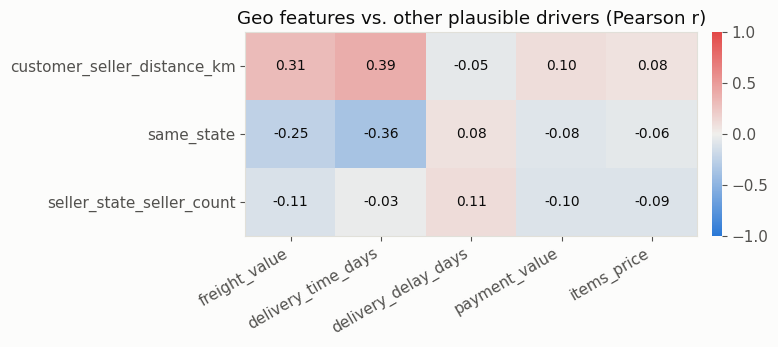

In [21]:
fig, ax = plt.subplots(figsize=(8, 3.6))
im = ax.imshow(construct_validity.values, cmap=DIVERGING, vmin=-1, vmax=1, aspect="auto")

ax.set_xticks(range(len(plausible_features)))
ax.set_xticklabels(plausible_features, rotation=30, ha="right")
ax.set_yticks(range(len(GEO_MODEL_COLS)))
ax.set_yticklabels(GEO_MODEL_COLS)

for i in range(construct_validity.shape[0]):
    for j in range(construct_validity.shape[1]):
        val = construct_validity.values[i, j]
        text_color = "white" if abs(val) > 0.55 else INK
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=text_color, fontsize=10)

ax.set_title("Geo features vs. other plausible drivers (Pearson r)")
cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.03)
cbar.outline.set_visible(False)
plt.tight_layout()
plt.show()

In [22]:
# Sanity check between the two geo_features.py outputs themselves: same_state=1
# should coincide with much shorter distances almost by construction.
geo_internal_corr = df[GEO_MODEL_COLS].corr(method="pearson")
geo_internal_corr

,customer_seller_distance_km,same_state,seller_state_seller_count
customer_seller_distance_km,1.000,-0.562,-0.159
same_state,-0.562,1.000,0.286
seller_state_seller_count,-0.159,0.286,1.000


In [23]:
print(f"Mean distance when same_state=1: {df.loc[df['same_state'] == 1, 'customer_seller_distance_km'].mean():,.1f} km")
print(f"Mean distance when same_state=0: {df.loc[df['same_state'] == 0, 'customer_seller_distance_km'].mean():,.1f} km")

Mean distance when same_state=1: 155.1 km
Mean distance when same_state=0: 856.7 km


## 8. What did the fitted model actually do with these features?

EDA makes the case that a feature is *worth trying*; this section closes the
loop with what `src/repeat_purchase_analysis.py`'s logistic regression
actually learned once it was included, pulled straight from the odds-ratio
table the training run wrote to `Dashboard/exports/repeat_purchase_odds_ratios.csv`.
Odds ratios come from a model with `StandardScaler`-scaled numeric inputs, so
each is "the odds multiplier for a one-standard-deviation increase in this
feature, holding the others fixed" - directly comparable across features
regardless of their raw units (km vs. seller count vs. 0/1).

In [24]:
odds_ratios = pd.read_csv(PROJECT_ROOT / "Dashboard" / "exports" / "repeat_purchase_odds_ratios.csv")
geo_odds = (
    odds_ratios[odds_ratios["feature"].isin(GEO_MODEL_COLS)]
    [["feature", "coefficient", "odds_ratio", "direction"]]
    .sort_values("coefficient")
    .reset_index(drop=True)
)
print(f"From model run: {odds_ratios['model'].iloc[0]}  (commit {odds_ratios['git_commit'].iloc[0][:8]})")
geo_odds

From model run: Logistic regression (base features)  (commit f714a325)


,feature,coefficient,odds_ratio,direction
0,customer_seller_distance_km,-0.139,0.870,lower repeat odds
1,same_state,-0.044,0.957,lower repeat odds
2,seller_state_seller_count,0.014,1.014,higher repeat odds


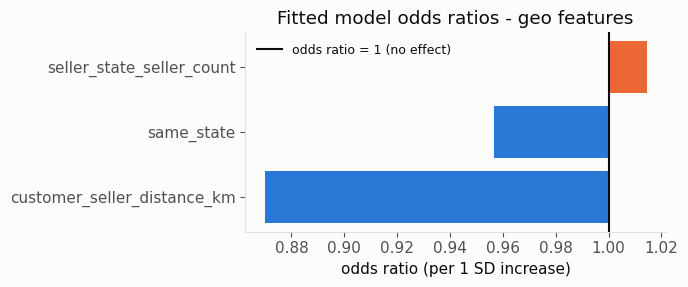

In [25]:
fig, ax = plt.subplots(figsize=(7, 3))
colors_odds = [ORANGE if v >= 1 else BLUE for v in geo_odds["odds_ratio"]]
ax.barh(geo_odds["feature"], geo_odds["odds_ratio"] - 1, left=1, color=colors_odds)
ax.axvline(1, color=INK, linewidth=1.5, label="odds ratio = 1 (no effect)")
ax.set_xlabel("odds ratio (per 1 SD increase)")
ax.set_title("Fitted model odds ratios - geo features")
ax.legend(frameon=False, fontsize=9)
style_axes(ax)
plt.tight_layout()
plt.show()

## 9. Stakeholder summary

Auto-generated from the numbers computed above, so it can't drift from the
analysis as the underlying data changes on a future ETL run.

In [26]:
n_total = len(df)
dist_missing_pct = df["customer_seller_distance_km"].isna().mean() * 100
same_state_missing_pct = df["same_state"].isna().mean() * 100

geo_rank = {row["feature"]: i + 1 for i, row in corr_table.iterrows()}

print("STAKEHOLDER SUMMARY - customer_seller_distance_km, same_state, seller_state_seller_count")
print("=" * 88)
print(f"Coverage: distance/same_state known for {100 - dist_missing_pct:.1f}% / {100 - same_state_missing_pct:.1f}%"
      f" of {n_total:,} first-time customers (missing only where zip-prefix geolocation or a seller record is absent).")
print()
print(f"Distance: mean {distance.mean():,.0f} km (median {distance.median():,.0f}, range {distance.min():,.0f}-{distance.max():,.0f} km).")
print(f"  Repeat buyers order from {abs(repeat_dist.mean() - onetime_dist.mean()):,.0f} km "
      f"{'farther' if repeat_dist.mean() > onetime_dist.mean() else 'closer'} on average than one-time buyers "
      f"(Welch's t={t_stat:.2f}, p={p_val:.4g}, Cohen's d={cohens_d_dist:.3f} - "
      f"{'a small but non-trivial' if abs(cohens_d_dist) >= 0.2 else 'a very small'} effect).")
print(f"  Ranked #{geo_rank['customer_seller_distance_km']} of {len(corr_table)} model features by |correlation| with repeat_purchase "
      f"(r={corr_table.set_index('feature').loc['customer_seller_distance_km', 'corr_with_target']:.4f}).")
print()
print(f"same_state: {same_state_table.loc['Same state (1)', 'pct_of_all_rows']:.1f}% of orders ship within the customer's own state.")
print(f"  Repeat rate {repeat_rate_by_match.loc['Same state', 'repeat_rate']:.2f}% (same state) vs. "
      f"{repeat_rate_by_match.loc['Different state', 'repeat_rate']:.2f}% (different state) "
      f"(chi2={chi2_state:.2f}, p={p_state:.4g}, Cramer's V={cramers_v_state:.4f} - "
      f"{'small' if cramers_v_state < 0.1 else 'small-to-moderate'} association).")
print(f"  Ranked #{geo_rank['same_state']} of {len(corr_table)} model features by |correlation| with repeat_purchase.")
print()
print(f"seller_state_seller_count: mean {seller_count.mean():,.0f} sellers (range {seller_count.min():,.0f}-{seller_count.max():,.0f}).")
print(f"  Welch's t={t_stat_ssc:.2f}, p={p_val_ssc:.4g}, Cohen's d={cohens_d_ssc:.3f}; "
      f"ranked #{geo_rank['seller_state_seller_count']} of {len(corr_table)} by |correlation| with the target.")
print()
print("Construct validity: distance vs. freight_value r="
      f"{construct_validity.loc['customer_seller_distance_km', 'freight_value']:.3f}, "
      "same_state vs. delivery_time_days r="
      f"{construct_validity.loc['same_state', 'delivery_time_days']:.3f} - "
      "both in the direction the underlying mechanism (shipping distance) predicts, "
      "which is evidence these features measure what they claim to, not noise.")
print()
print("Fitted model: see section 8's odds-ratio table for the sign/size each feature was")
print("actually assigned once trained alongside the rest of NUMERIC_FEATURES.")
print()
print("Caveat for stakeholders: with n in the tens of thousands, p-values are small even for")
print("tiny effects - the odds ratios and Cohen's d / Cramer's V above are the numbers that")
print("say whether an effect is big enough to act on, not the p-value alone.")

STAKEHOLDER SUMMARY - customer_seller_distance_km, same_state, seller_state_seller_count
Coverage: distance/same_state known for 99.5% / 100.0% of 83,644 first-time customers (missing only where zip-prefix geolocation or a seller record is absent).

Distance: mean 609 km (median 441, range 0-5,339 km).
  Repeat buyers order from 51 km closer on average than one-time buyers (Welch's t=-4.75, p=2.133e-06, Cohen's d=-0.085 - a very small effect).
  Ranked #3 of 11 model features by |correlation| with repeat_purchase (r=-0.0152).

same_state: 35.2% of orders ship within the customer's own state.
  Repeat rate 3.46% (same state) vs. 3.23% (different state) (chi2=3.03, p=0.08188, Cramer's V=0.0060 - small association).
  Ranked #9 of 11 model features by |correlation| with repeat_purchase.

seller_state_seller_count: mean 1,376 sellers (range 1-1,849).
  Welch's t=1.21, p=0.2278, Cohen's d=0.023; ranked #10 of 11 by |correlation| with the target.

Construct validity: distance vs. freight_val